In [3]:
import tensorflow as tf
from keras import layers
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
import numpy as np
import cv2
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import Callback, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from tensorflow.keras.callbacks import Callback , ReduceLROnPlateau , ModelCheckpoint, CSVLogger
from sklearn.metrics import cohen_kappa_score, accuracy_score
from tensorflow.keras.losses import categorical_crossentropy as logloss
from tensorflow.keras.metrics import categorical_accuracy
import pandas as pd 
import os
from PIL import Image
import scipy
from sklearn import metrics
from sklearn.model_selection import train_test_split
import json

In [1]:
train_dir = 'Dataset(1)/Train'
valid_dir = 'Dataset(1)/Validation'
test_dir = 'Dataset(1)/Test'

Target folder: Dataset(1)/Train\Real
[1] real_64017.jpg - Shape: (256, 256, 3)
[2] real_42928.jpg - Shape: (256, 256, 3)
[3] real_60320.jpg - Shape: (256, 256, 3)
[4] real_32912.jpg - Shape: (256, 256, 3)
[5] real_50.jpg - Shape: (256, 256, 3)
[6] real_367.jpg - Shape: (256, 256, 3)
[7] real_59709.jpg - Shape: (256, 256, 3)
[8] real_5539.jpg - Shape: (256, 256, 3)
[9] real_29260.jpg - Shape: (256, 256, 3)
[10] real_65945.jpg - Shape: (256, 256, 3)


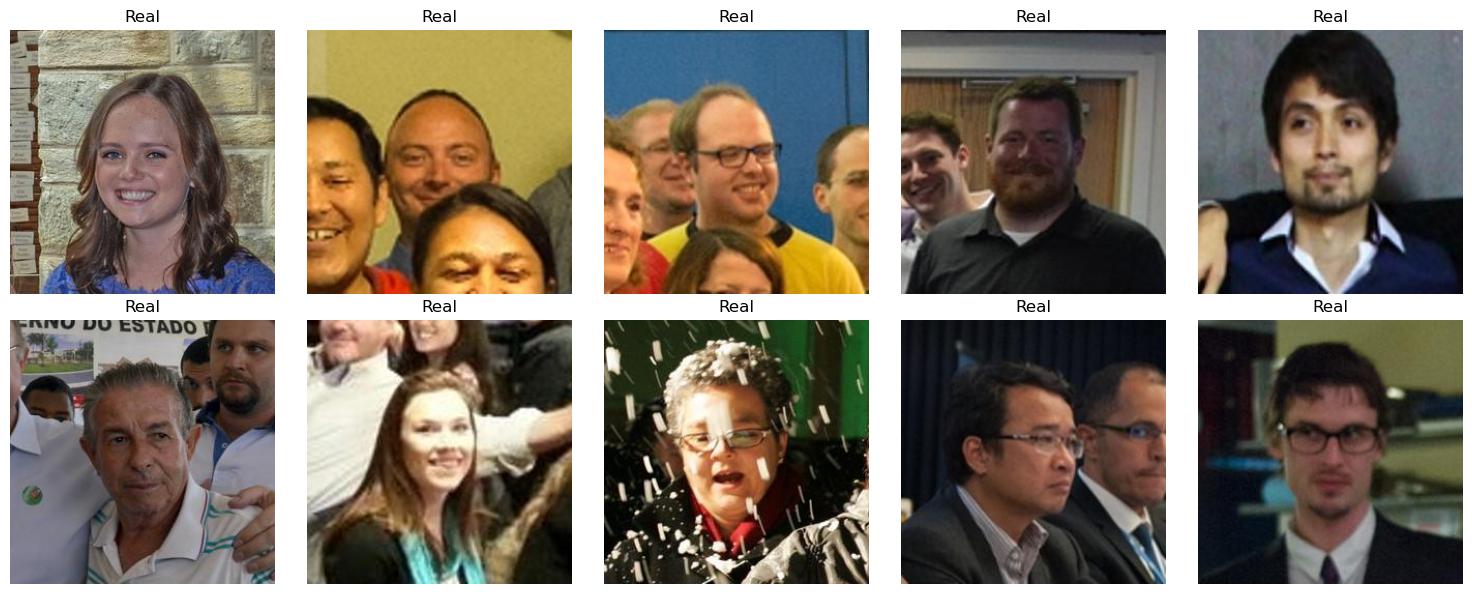

In [6]:
# View an image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

def view_random_images(target_dir, target_class, num_images=10):
    target_folder = os.path.join(target_dir, target_class)
    print(f"Target folder: {target_folder}")

    # Sample multiple images
    image_files = random.sample(os.listdir(target_folder), num_images)

    # Setup figure to display multiple images
    plt.figure(figsize=(15, 6))
    for i, image_file in enumerate(image_files):
        img_path = os.path.join(target_folder, image_file)
        img = mpimg.imread(img_path)

        plt.subplot(2, 5, i + 1)  # 2 rows x 5 columns
        plt.imshow(img)
        plt.title(target_class)
        plt.axis("off")

        print(f"[{i+1}] {image_file} - Shape: {img.shape}")

    plt.tight_layout()
    plt.show()

# # View random real image
img = view_random_images(target_dir=train_dir, 
                   target_class="Real")


Target folder: Dataset(1)/Train\Fake
[1] fake_40488.jpg - Shape: (256, 256, 3)
[2] fake_960.jpg - Shape: (256, 256, 3)
[3] fake_52652.jpg - Shape: (256, 256, 3)
[4] fake_23958.jpg - Shape: (256, 256, 3)
[5] fake_4842.jpg - Shape: (256, 256, 3)
[6] fake_14010.jpg - Shape: (256, 256, 3)
[7] fake_19983.jpg - Shape: (256, 256, 3)
[8] fake_51944.jpg - Shape: (256, 256, 3)
[9] fake_33795.jpg - Shape: (256, 256, 3)
[10] fake_14890.jpg - Shape: (256, 256, 3)


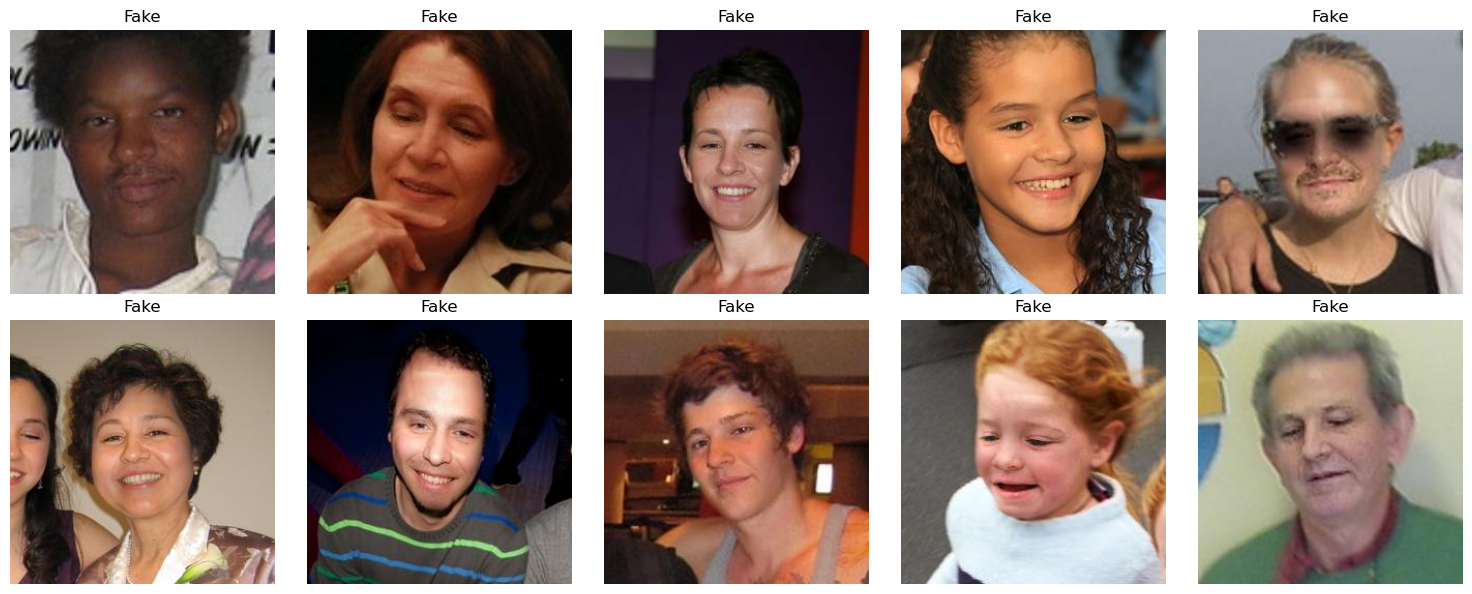

In [11]:
# # View random fake image
img = view_random_images(target_dir=train_dir,
                      target_class="Fake")

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

train_datagen = ImageDataGenerator(rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(valid_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=1,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               shuffle=False,
                                               seed=42)

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


In [10]:
def load_and_prep_image(filename, img_shape=224):
  # Read in target file (an image)
  print(filename)
  img = tf.io.read_file(filename)

  img = tf.image.decode_image(img, channels=3)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255.
  return img

print(test_data[0])

(array([[[[0.01568628, 0.01568628, 0.01568628],
         [0.01176471, 0.01176471, 0.01176471],
         [0.00784314, 0.00784314, 0.00784314],
         ...,
         [0.1764706 , 0.05882353, 0.01568628],
         [0.16078432, 0.04313726, 0.        ],
         [0.14901961, 0.03137255, 0.        ]],

        [[0.01568628, 0.01568628, 0.01568628],
         [0.01176471, 0.01176471, 0.01176471],
         [0.00784314, 0.00784314, 0.00784314],
         ...,
         [0.18039216, 0.0627451 , 0.01960784],
         [0.16470589, 0.04705883, 0.00392157],
         [0.15294118, 0.03529412, 0.        ]],

        [[0.01568628, 0.01568628, 0.01568628],
         [0.01176471, 0.01176471, 0.01176471],
         [0.00784314, 0.00784314, 0.00784314],
         ...,
         [0.18431373, 0.06666667, 0.02352941],
         [0.17254902, 0.05490196, 0.01176471],
         [0.16078432, 0.04313726, 0.        ]],

        ...,

        [[0.02745098, 0.02745098, 0.02745098],
         [0.03137255, 0.03137255, 0.03137255

In [9]:
print(test_data)

In [10]:
# pred = model_1.predict(test_data[9000])
# ctr = 1 if pred > .50 else 0 
# print()
# pred

In [11]:
# End to End TinyVGG Model

tf.random.set_seed(42)


#Create a CNN model
#(same as Tiny VGG - https://poloclub.github.io/cnn-explainer/)


model_1 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=20, 
                         kernel_size=3, # can also be (3, 3)
                         activation="relu", 
                         input_shape=(224, 224, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(20, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(20, 3, activation="relu"),
  tf.keras.layers.Conv2D(20, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(4),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

# Compile the model
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])



In [13]:
# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5, #5, 8
                        steps_per_epoch=128, # 44, 99, 128, 4k XD
                        validation_data=valid_data,
                        validation_steps=128)

Epoch 1/5
128/128 [==============================] - 253s 2s/step - loss: 0.6910 - accuracy: 0.5334 - val_loss: 0.6784 - val_accuracy: 0.5959
Epoch 2/5
128/128 [==============================] - 232s 2s/step - loss: 0.6721 - accuracy: 0.5869 - val_loss: 0.6451 - val_accuracy: 0.6289
Epoch 3/5
128/128 [==============================] - 231s 2s/step - loss: 0.6542 - accuracy: 0.6204 - val_loss: 0.6277 - val_accuracy: 0.6416
Epoch 4/5
128/128 [==============================] - 234s 2s/step - loss: 0.6491 - accuracy: 0.6284 - val_loss: 0.6180 - val_accuracy: 0.6777
Epoch 5/5
128/128 [==============================] - 256s 2s/step - loss: 0.6412 - accuracy: 0.6248 - val_loss: 0.6065 - val_accuracy: 0.6877


In [24]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix


# func to generate different score and confusion matrix from test score.
def gen_test_data(model):
    # Generate Confusion Matrix
    y_pred = model.predict(test_data)
    y_test = test_data.classes
    
#     y_pred_labels = np.argmax(y_pred, axis=1)
    y_pred_labels = (y_pred > 0.5).astype(np.float32)

    confusion_mat = confusion_matrix(y_test, y_pred_labels)
    print(confusion_mat)
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_mat, display_labels = [False, True])

    cm_display.plot()
    plt.show()
    
    # Get AUC, ROC and Precision Score
    print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred))
    print("AP Score:", metrics.average_precision_score(y_test, y_pred))
    print()
    print(metrics.classification_report(y_test, y_pred_labels))
    _, accu = model.evaluate(test_data)
    print('Final Test Acccuracy = {:.3f}'.format(accu*100))
    

10905/10905 [==============================] - 164s 15ms/step
[[4033 1459]
 [2606 2807]]


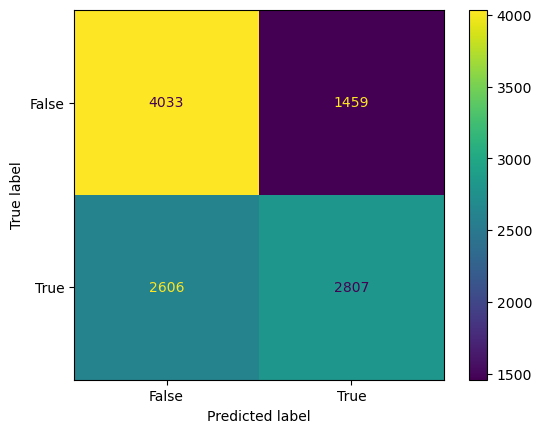

ROC AUC Score: 0.6974495694256052
AP Score: 0.6589733906948048

              precision    recall  f1-score   support

           0       0.61      0.73      0.66      5492
           1       0.66      0.52      0.58      5413

    accuracy                           0.63     10905
   macro avg       0.63      0.63      0.62     10905
weighted avg       0.63      0.63      0.62     10905

10905/10905 [==============================] - 133s 12ms/step - loss: 0.6358 - accuracy: 0.6272
Final Test Acccuracy = 62.724


In [ ]:

gen_test_data(model_1)

In [23]:
#Save the model
model_1.save("VGG_1.h5")

def load_and_prep_image(filename, img_shape=224):
  # Read in target file (an image)
  print(filename)
  img = tf.io.read_file(filename)

  img = tf.image.decode_image(img, channels=3)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255.
  return img

test_img = load_and_prep_image(f"{test_dir}/Real/real_4.jpg")
test_img = tf.expand_dims(test_img, axis=0)

import keras
model_1.save("VGG_01_FINAL.keras")


Dataset(1)/Test/Real/real_4.jpg


In [25]:
reconstructed_model = keras.models.load_model("VGG_01_FINAL.keras")

# Let's check:
print(np.testing.assert_allclose(
    model_1.predict(test_img), reconstructed_model.predict(test_img)
))

1/1 [==============================] - 0s 64ms/step
None


In [28]:
from keras.models import load_model
vgg_1 = load_model('VGG_1.h5')

In [29]:
def load_and_prep_image(filename, img_shape=224):
  # Read in target file (an image)
  print(filename)
  img = tf.io.read_file(filename)

  img = tf.image.decode_image(img, channels=3)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255.
  return img

test_img = load_and_prep_image(f"{test_dir}/Real/real_4.jpg")
test_img = tf.expand_dims(test_img, axis=0)
vgg_1.predict(test_img)

Dataset(1)/Test/Real/real_4.jpg
1/1 [==============================] - 0s 63ms/step


array([[0.7806577]], dtype=float32)

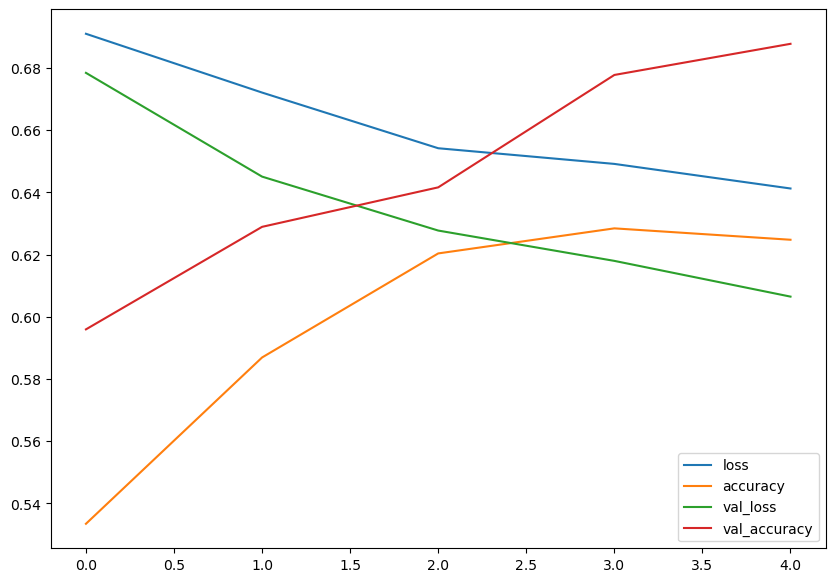

In [30]:
import pandas as pd
pd.DataFrame(history_1.history).plot(figsize=(10, 7));

In [12]:
# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

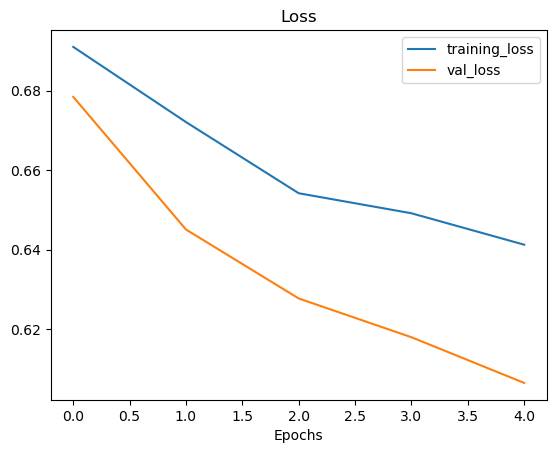

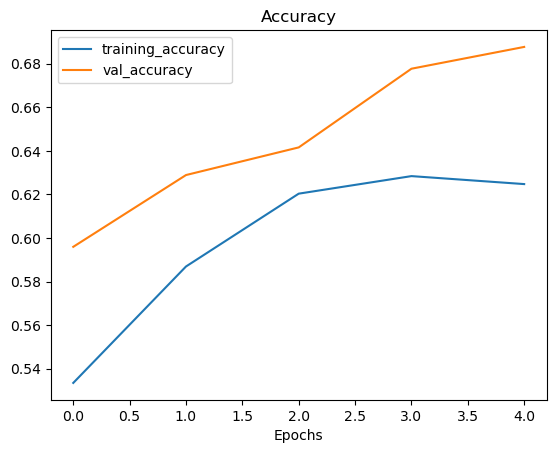

In [ ]:

plot_loss_curves(history_1)

In [34]:
# model_2 with a MaxPool2D layer after every Conv2D layer

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

tf.random.set_seed(42)

model_2 = Sequential([
  Conv2D(20, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(20, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(20, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

model_2.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

history_2 = model_2.fit(train_data,
                        epochs=6,
                        steps_per_epoch=256,
                        validation_data=valid_data,
                        validation_steps=256)

Epoch 1/6
256/256 [==============================] - 314s 1s/step - loss: 0.6800 - accuracy: 0.5688 - val_loss: 0.6634 - val_accuracy: 0.5986
Epoch 2/6
256/256 [==============================] - 284s 1s/step - loss: 0.6620 - accuracy: 0.6001 - val_loss: 0.6909 - val_accuracy: 0.5488
Epoch 3/6
256/256 [==============================] - 269s 1s/step - loss: 0.6582 - accuracy: 0.6087 - val_loss: 0.6403 - val_accuracy: 0.6317
Epoch 4/6
256/256 [==============================] - 249s 973ms/step - loss: 0.6406 - accuracy: 0.6379 - val_loss: 0.6254 - val_accuracy: 0.6549
Epoch 5/6
256/256 [==============================] - 240s 937ms/step - loss: 0.6346 - accuracy: 0.6400 - val_loss: 0.6106 - val_accuracy: 0.6697
Epoch 6/6
256/256 [==============================] - 236s 924ms/step - loss: 0.6250 - accuracy: 0.6530 - val_loss: 0.6350 - val_accuracy: 0.6244


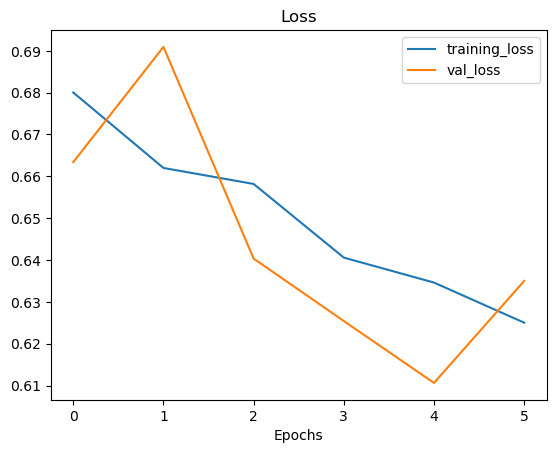

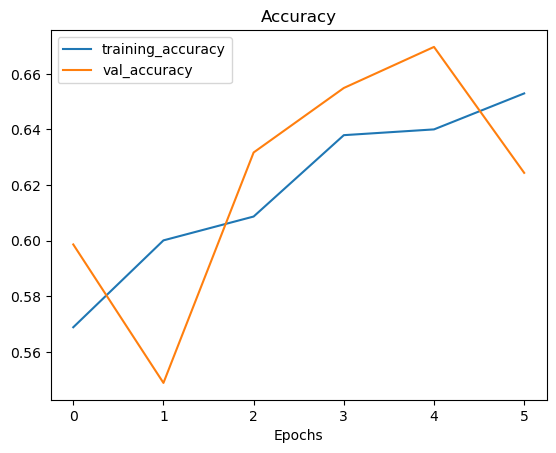

In [35]:
plot_loss_curves(history_2)

In [36]:
model_2.save("VGG_2_FINAL.h5")

10905/10905 [==============================] - 124s 11ms/step
[[1915 3577]
 [ 629 4784]]


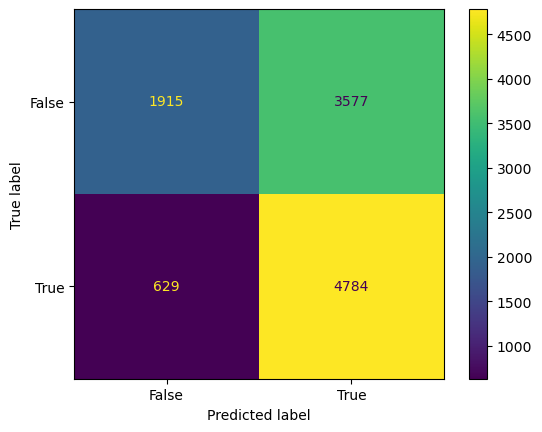

ROC AUC Score: 0.6838908085778228
AP Score: 0.6568589209329446

              precision    recall  f1-score   support

           0       0.75      0.35      0.48      5492
           1       0.57      0.88      0.69      5413

    accuracy                           0.61     10905
   macro avg       0.66      0.62      0.59     10905
weighted avg       0.66      0.61      0.58     10905

10905/10905 [==============================] - 75s 7ms/step - loss: 0.6576 - accuracy: 0.6143
Final Test Acccuracy = 61.431


In [37]:
# Todo: Try DataAugmentation during image preprocessing.
gen_test_data(model_2)

In [38]:
def load_and_prep_image(filename, img_shape=224):
  # Read in target file (an image)
  print(filename)
  img = tf.io.read_file(filename)

  img = tf.image.decode_image(img, channels=3)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255.
  return img

In [39]:
train_img_path_1 = f"{test_dir}/Real/real_4.jpg"
train_img_path_2 = f"{test_dir}/Fake/fake_12.jpg"
train_img_real_1 = load_and_prep_image(train_img_path_1)
train_img_real_2 = load_and_prep_image(train_img_path_2)
train_img_real_1 = tf.expand_dims(train_img_real_1, axis=0)
train_img_real_2 = tf.expand_dims(train_img_real_2, axis=0)

Dataset(1)/Test/Real/real_4.jpg
Dataset(1)/Test/Fake/fake_12.jpg


In [40]:
pred_1 = model_2.predict(train_img_real_1)
pred_2 = model_2.predict(train_img_real_2)
print(pred_1)
print(pred_2)


1/1 [==============================] - 0s 21ms/step
[[0.84468234]]
[[0.73270726]]


In [7]:
input_shape=(224,224,3)
batch_size=64


def build_model():
    res_densenet = ResNet50(
                        weights='imagenet',
                        include_top=False,
                        input_shape=input_shape
                        )
    res_model = Sequential([res_densenet,
                        layers.GlobalAveragePooling2D(),
                        layers.Dense(64,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dropout(0.5),
                        layers.Dense(1, activation='sigmoid')
                        ])
    res_model.compile(optimizer=Adam(),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return res_model


model_resnet = build_model()
model_resnet.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 64)                131136    
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 6

## !!!!!!!run with 8 epochs not 1 AND STEPS_PER_EPOCH AS 256 NOT 128!!!!!!! ##

In [ ]:
##run with 8 epochs instead no time rn....will run later

In [11]:
tf.random.set_seed(42)
history = model_resnet.fit(train_data,
    epochs = 3, #8
    steps_per_epoch = 256, 
    validation_data =valid_data,
    validation_steps = 256
)

Epoch 1/3
256/256 [==============================] - 2134s 8s/step - loss: 0.4645 - accuracy: 0.7909 - val_loss: 0.7914 - val_accuracy: 0.5007
Epoch 2/3
256/256 [==============================] - 2123s 8s/step - loss: 0.3101 - accuracy: 0.8699 - val_loss: 0.6929 - val_accuracy: 0.5042
Epoch 3/3
256/256 [==============================] - 2085s 8s/step - loss: 0.2368 - accuracy: 0.9041 - val_loss: 0.7006 - val_accuracy: 0.7156


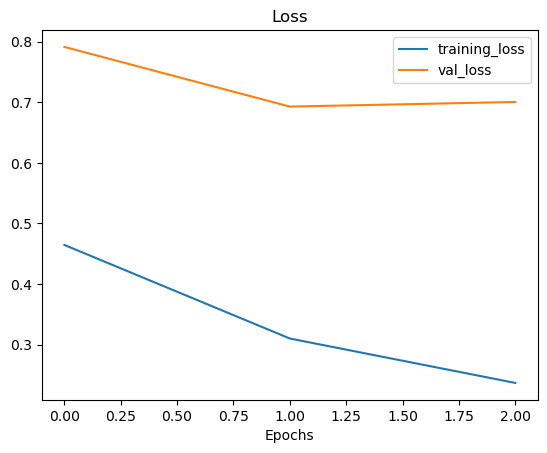

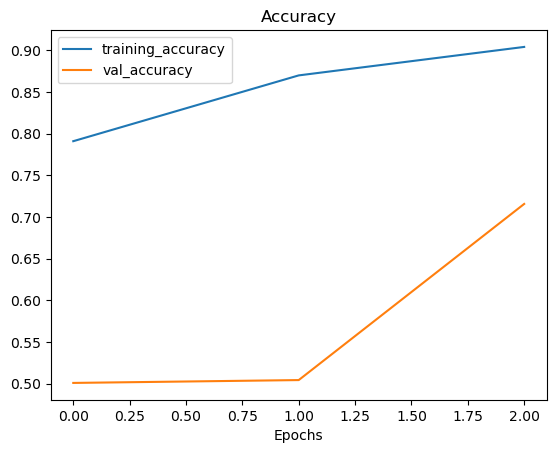

In [13]:
plot_loss_curves(history)

In [19]:
# ResNet50_1 Save
import keras
model_resnet.save("Res_01_FINAL.keras")
reconstructed_model = keras.models.load_model("Res_01_FINAL.keras")

# # Let's check:
# np.testing.assert_allclose(
#     model.predict(test_input), reconstructed_model.predict(test_input)
# )

In [20]:
filename = 'ResNet50_1.pkl'
# pickle.dump(model_resnet, open(filename, 'wb'))

In [21]:
def load_and_prep_image(filename, img_shape=224):
  # Read in target file (an image)
  print(filename)
  img = tf.io.read_file(filename)

  img = tf.image.decode_image(img, channels=3)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255.
  return img

test_img = load_and_prep_image(f"{test_dir}/Fake/fake_10.jpg")
test_img = tf.expand_dims(test_img, axis=0)
model_resnet.predict(test_img)

Dataset(1)/Test/Fake/fake_10.jpg
1/1 [==============================] - 1s 1s/step


array([[0.83299524]], dtype=float32)

In [22]:
from keras.models import load_model
vggyo = load_model('Res_01_FINAL.keras')
vggyo.predict(test_img)
def load_and_prep_image(filename, img_shape=224):
  # Read in target file (an image)
  print(filename)
  img = tf.io.read_file(filename)

  img = tf.image.decode_image(img, channels=3)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255.
  return img

test_img = load_and_prep_image(f"{test_dir}/Real/real_4.jpg")
test_img = tf.expand_dims(test_img, axis=0)
vggyo.predict(test_img)

1/1 [==============================] - 1s 940ms/step
Dataset(1)/Test/Real/real_4.jpg
1/1 [==============================] - 0s 85ms/step


array([[0.9990546]], dtype=float32)

10905/10905 [==============================] - 853s 78ms/step
[[2528 2964]
 [ 232 5181]]


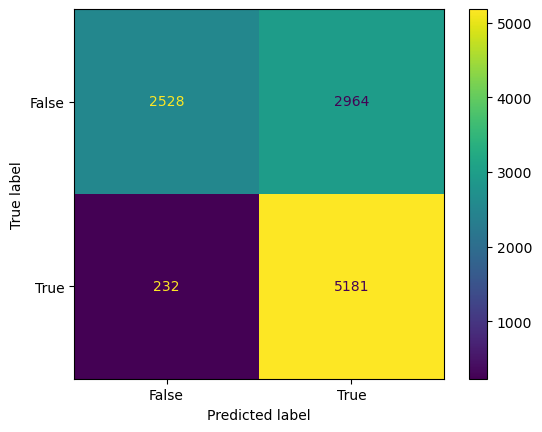

ROC AUC Score: 0.8062850836962997
AP Score: 0.7952943754391781

              precision    recall  f1-score   support

           0       0.92      0.46      0.61      5492
           1       0.64      0.96      0.76      5413

    accuracy                           0.71     10905
   macro avg       0.78      0.71      0.69     10905
weighted avg       0.78      0.71      0.69     10905

10905/10905 [==============================] - 1091s 100ms/step - loss: 0.7010 - accuracy: 0.7069
Final Test Acccuracy = 70.692


In [25]:
gen_test_data(model_resnet)

### !!!!!RUN PREVIOUS ONE AGAIN WITH BETTER EPOCHS !!!!!!

### that's it for now...build model 2 later... ##

In [26]:
def build_model_2():
    densenet = ResNet50(
                        weights='imagenet',
                        include_top=False,
                        input_shape=input_shape
                        )
    model = Sequential([densenet,
                        layers.GlobalAveragePooling2D(),
                        layers.Dense(512,activation='relu'),
                        layers.Dense(128,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(64,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(64,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dropout(0.5),
                        layers.Dense(128,activation='relu'),
                        layers.Flatten(),
                        layers.Dense(128,activation='relu'),
                        layers.Dense(1, activation='sigmoid')
                        ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return model


model_resnet_2 = build_model_2()
model_resnet_2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 512)               1049088   
                                                                 
 dense_3 (Dense)             (None, 128)               65664     
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dense_4 (Dense)             (None, 64)               

In [31]:
tf.random.set_seed(42)
history_resnet_2 = model_resnet_2.fit(train_data,
    epochs = 16,
    steps_per_epoch = 128,
    validation_data =valid_data,
    validation_steps = 126
)

Epoch 1/16
128/128 [==============================] - 1240s 10s/step - loss: 0.4010 - accuracy: 0.8364 - val_loss: 0.7644 - val_accuracy: 0.5074
Epoch 2/16
128/128 [==============================] - 1046s 8s/step - loss: 0.2471 - accuracy: 0.9048 - val_loss: 0.8935 - val_accuracy: 0.4933
Epoch 3/16
128/128 [==============================] - 982s 8s/step - loss: 0.2070 - accuracy: 0.9238 - val_loss: 0.8444 - val_accuracy: 0.4705
Epoch 4/16
128/128 [==============================] - 971s 8s/step - loss: 0.1613 - accuracy: 0.9453 - val_loss: 0.7151 - val_accuracy: 0.6089
Epoch 5/16
128/128 [==============================] - 985s 8s/step - loss: 0.2008 - accuracy: 0.9211 - val_loss: 0.7938 - val_accuracy: 0.6052
Epoch 6/16
128/128 [==============================] - 1001s 8s/step - loss: 0.1492 - accuracy: 0.9438 - val_loss: 0.4713 - val_accuracy: 0.7684
Epoch 7/16
128/128 [==============================] - 971s 8s/step - loss: 0.1315 - accuracy: 0.9509 - val_loss: 0.2459 - val_accuracy: 0.

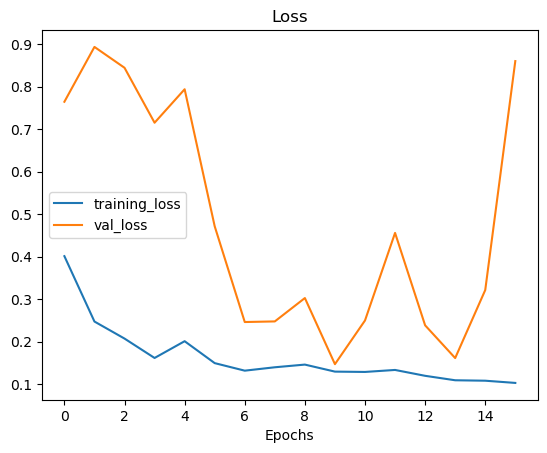

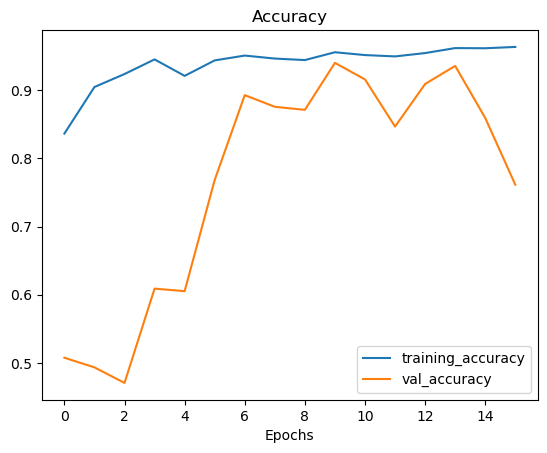

In [33]:
plot_loss_curves(history_resnet_2)

10905/10905 [==============================] - 788s 72ms/step
[[5425   67]
 [2989 2424]]


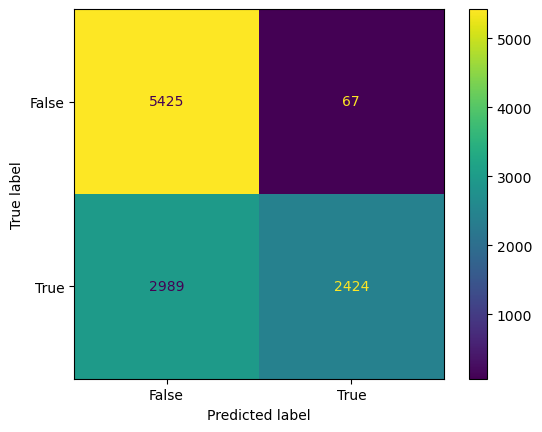

ROC AUC Score: 0.9264088375897415
AP Score: 0.9285257653320551

              precision    recall  f1-score   support

           0       0.64      0.99      0.78      5492
           1       0.97      0.45      0.61      5413

    accuracy                           0.72     10905
   macro avg       0.81      0.72      0.70     10905
weighted avg       0.81      0.72      0.70     10905

10905/10905 [==============================] - 753s 69ms/step - loss: 0.8311 - accuracy: 0.7198
Final Test Acccuracy = 71.976


In [36]:
gen_test_data(model_resnet_2)

In [40]:
# ResNet50_1 Save
import keras
model_resnet_2.save("Res_02_FINAL.keras")
# ResNet50_2 Save
model_resnet_2.save("ResNet50_2.h5")


In [38]:
# tf.random.set_seed(42)
# history_resnet_2 = model_resnet_2.fit(train_data,
#     epochs = 6,
#     steps_per_epoch = 1024,
#     validation_data =valid_data,
#     validation_steps = 1024
# )

In [39]:
# plot_loss_curves(history_resnet_2)

###IceptionNET###

In [41]:
from keras.applications.inception_v3 import InceptionV3

input_shape=(224,224,3)
batch_size=64

def build_model_inception():
    densenet = InceptionV3(
                        weights='imagenet',
                        include_top=False,
                        input_shape=input_shape,
                        )
    model = Sequential([densenet,
                        layers.GlobalAveragePooling2D(),
                        layers.Dense(512,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(256,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(128,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dropout(0.5),
                        layers.Dense(1, activation='sigmoid')
                        ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return model

model_icv3 = build_model_inception()
model_icv3.summary()


87910968/87910968 [==============================] - 23s 0us/step
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_9 (Dense)             (None, 512)               1049088   
                                                                 
 batch_normalization_192 (Ba  (None, 512)              2048      
 tchNormalization)                                               
                                                                 
 dense_10 (Dense)            (None, 256)               131328    
                                                      

In [43]:
tf.random.set_seed(42)
history_icv3 = model_icv3.fit(train_data,
    epochs = 5, #8
    steps_per_epoch = 1024,
    validation_data =valid_data,
    validation_steps = 1024
)

Epoch 1/5
1024/1024 [==============================] - 4998s 5s/step - loss: 0.2738 - accuracy: 0.8940 - val_loss: 0.1865 - val_accuracy: 0.9303
Epoch 2/5
1024/1024 [==============================] - 4857s 5s/step - loss: 0.1366 - accuracy: 0.9489 - val_loss: 0.2199 - val_accuracy: 0.9196
Epoch 3/5
1024/1024 [==============================] - 4821s 5s/step - loss: 0.1131 - accuracy: 0.9581 - val_loss: 0.1461 - val_accuracy: 0.9397
Epoch 4/5
1024/1024 [==============================] - 4833s 5s/step - loss: 0.0921 - accuracy: 0.9661 - val_loss: 0.1351 - val_accuracy: 0.9513
Epoch 5/5
1024/1024 [==============================] - 4981s 5s/step - loss: 0.0775 - accuracy: 0.9713 - val_loss: 0.0931 - val_accuracy: 0.9641


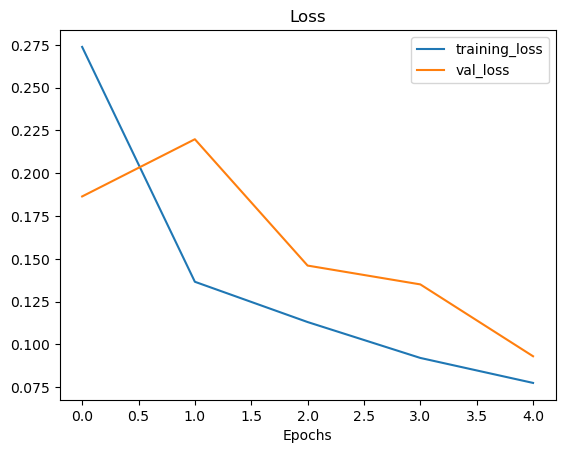

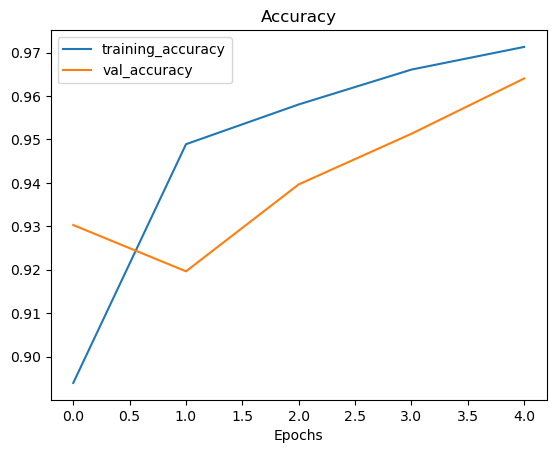

In [44]:
plot_loss_curves(history_icv3)

In [45]:
# InceptionNetV3_1 Save
# ResNet50_1 Save
import keras
model_icv3.save("ICV3_FINAL.keras")

filename = 'InceptionNetV3_1.pkl'
# pickle.dump(model_icv3, open(filename, 'wb'))

In [ ]:
# tf.random.set_seed(42)
# history_icv3_2 = model_icv3.fit(train_data,
#     epochs = 24,
#     steps_per_epoch = 1024,
#     validation_data =valid_data,
#     validation_steps = 1024
# )

In [ ]:
# plot_loss_curves(history_icv3_2)

10905/10905 [==============================] - 604s 55ms/step
[[5178  314]
 [1296 4117]]


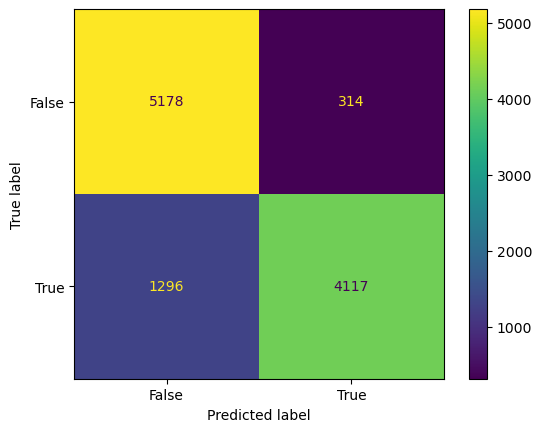

ROC AUC Score: 0.9421960888578642
AP Score: 0.9477711550866288

              precision    recall  f1-score   support

           0       0.80      0.94      0.87      5492
           1       0.93      0.76      0.84      5413

    accuracy                           0.85     10905
   macro avg       0.86      0.85      0.85     10905
weighted avg       0.86      0.85      0.85     10905

10905/10905 [==============================] - 613s 56ms/step - loss: 0.5840 - accuracy: 0.8524
Final Test Acccuracy = 85.236


In [46]:
gen_test_data(model_icv3)